# Paper figures

Here we reproduce the figures in the order they appear in the paper.

In [2]:
# Import libraries

from src.spectrogram import *
from src.barycenter import *
from src.cost_matrix import *
from src.display import *
from src.spectrogram import *
from src.experiment_metrics import *
from src.utils import *

import os
import matplotlib.pyplot as plt
import librosa
from scipy.signal.windows import hann

from time import time
from tqdm import tqdm

## Fig. 1 - Effects of window length on the spectrogram

Computing UOT... Convergence attained after 50 iterations.


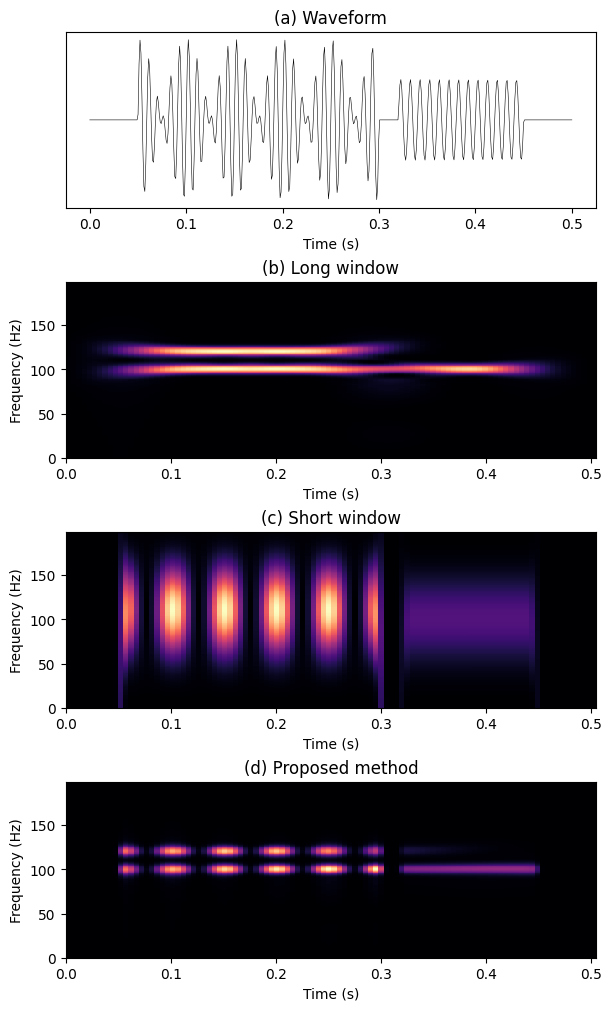

In [3]:
sr = 1000 # sample rate
t, signal = generate_toy_signal(sr)

# Ccompute input spectrograms
X1 = Spectrogram(signal, sr=sr, window_size_s=180e-3, hop_size_s=5e-3, nfft=1024)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3, hop_size_s=5e-3, nfft=1024)

x1 = X1.spectrogram()
x2 = X2.spectrogram()

## Compute UOT over same support spectrograms
# First truncate last frames of x1 to ensure same shape
# This is the "same-grid" setting, see for example V.A for a discussion.

x1 = x1[:, :X2.t] # X2.t is the number of frames in x2
X1.t_frames = X1.t_frames[:X2.t]

# Build cost matrices
c1, rows1, cols1 = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

print("Computing UOT...", end=' ')
x_uot, loss, diff = uot_barycenter(x1.T.flatten(), 
                                   x2.T.flatten(), 
                                   c1, 
                                   c2, 
                                   rows1,
                                   cols1,
                                   rows2,
                                   cols2,
                                   eta=100,
                                   bary_size=x1.shape[0] * x2.shape[1],
                                   nItermax=500,
                                   verbose=True,
                                   return_loss=True,
                                   return_diff=True,
                                   thr=1e-5)

x_uot = x_uot.reshape(X2.t, X1.f).T

axes = new_axes(4, 1, figsize=[6, 10]) # 4 rows, 1 col
plot_signal(signal, times=t, ax=axes[0], title='(a) Waveform')
display_spectrogram(x1, ax=axes[1], f_bins=X1.f_bins, t_frames=X1.t_frames, high_f=200, title='(b) Long window') # in paper we remove last frames of x1 for readability
display_spectrogram(x2, ax=axes[2], f_bins=X2.f_bins, t_frames=X2.t_frames, high_f=200, title='(c) Short window')
display_spectrogram(x_uot, ax=axes[3], f_bins=X1.f_bins, t_frames=X2.t_frames, high_f=200, title='(d) Proposed method')

## Fig. 2 - Time-frequency grids used for OT

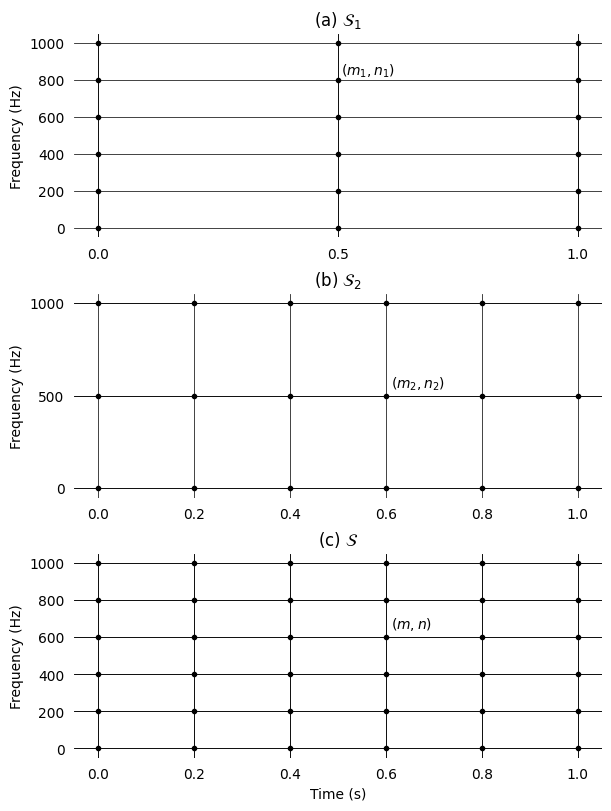

In [4]:
f_bins_1   = np.linspace(0, 1000, 6) # 6 bins from 0 to 1kHz
f_bins_2   = np.linspace(0, 1000, 3) # 3 bins from 0 to 1kHz

t_frames_1 = np.linspace(0, 1, 3) # 3 frames from 0 to 1 second
t_frames_2 = np.linspace(0, 1, 6) # 6 frames from 0 to 1 second

S1 = time_freq_support(f_bins_1, t_frames_1)
S2 = time_freq_support(f_bins_2, t_frames_2)
S  = time_freq_support(f_bins_1, t_frames_2)

axes = new_axes(3, 1, figsize=[6, 8])

display_support(S1, ax=axes[0], title=r'(a) $\mathcal{S}_1$', xlabel='', add_point=True, point_pos=(.505, .86), point_label=r'$(m_1, n_1)$')
display_support(S2, ax=axes[1], title=r'(b) $\mathcal{S}_2$', xlabel='', add_point=True, point_pos=(.6, .6), point_label=r'$(m_2, n_2)$')
display_support(S , ax=axes[2], title=r'(c) $\mathcal{S}$', add_point=True, point_pos=(.6, .7), point_label=r'$(m, n)$')

## Fig. 3 - Initial results

### Load signal and spectrograms

/Users/davidv/david/code/papers/fusion-ot/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


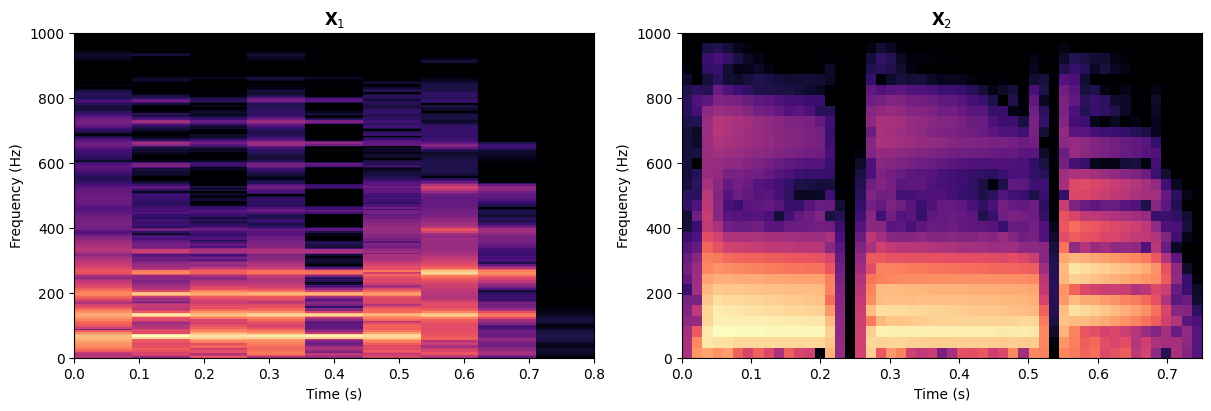

In [5]:
sr = 2000 # setting sr low to run OT (might need to reduce this further if OT doesn't work)
signal, _ = librosa.load('example_sounds/bass_notes.wav', sr=sr) 

X1 = Spectrogram(signal, sr=sr, window_size_s=200e-3)
X2 = Spectrogram(signal, sr=sr, window_size_s=30e-3)
x1 = X1.spectrogram()
x1 /= x1.sum() # normalization required for OT
x2 = X2.spectrogram()
x2 /= x2.sum() # normalization required for OT

axes = new_axes(1, 2)

display_spectrogram(x1, ax=axes[0], f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-80, title=r"$\mathbf{X}_1$")
display_spectrogram(x2, ax=axes[1], f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-80, title=r"$\mathbf{X}_2$")

### Squared Euclidean OT

Compute cost matrices for OT

In [6]:
C1 = sq_cost_matrix(X1.f_bins, X1.t_frames, X1.f_bins, X2.t_frames)
C2 = sq_cost_matrix(X2.f_bins, X2.t_frames, X1.f_bins, X2.t_frames)

print(f"C1 has {C1.size} finite values.")
print(f"C2 has {C2.size} finite values.")

C1 has 18544059 finite values.
C2 has 16206831 finite values.


Compute OT barycenter

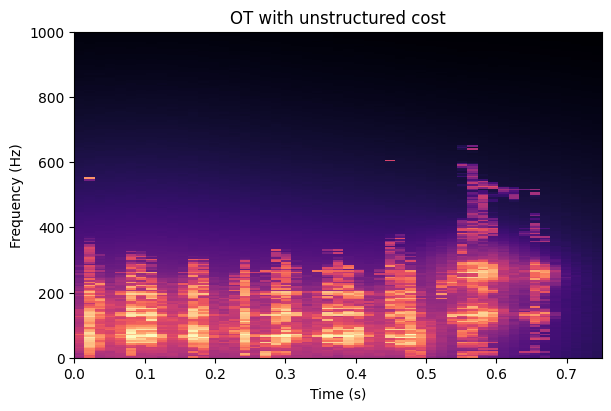

In [7]:
# take x.T.flatten() so that weights are vectorized in a column-wise fashion.

# UNCOMMENT THE FOLLOWING LINES TO COMPUTE THE OT BARYCENTER
# TAKES A LONG TIME (for 1000 iterations)
# x_OT, loss_OT, diff_OT = ot_barycenter(x1.T.flatten(), x2.T.flatten(), C1, C2, nItermax=1000, thr=0, return_diff=True, return_loss=True, verbose=True)
# x_OT = x_OT.reshape(X2.t, X1.f).T
# np.save('data/ot_barycenter.npy', x_OT)
# np.save('data/ot_loss.npy', loss_OT)
# np.save('data/ot_diff.npy', diff_OT)

# LOAD THE OT BARYCENTER DIRECTLY
x_OT = np.load('data/ot_barycenter.npy')

display_spectrogram(x_OT, f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='OT with unstructured cost')

### Structured cost matrices + UOT

Compute structured cost matrices in Section III. D to know how many finite entries they have.

In [8]:
c1 = cost_matrix_horizontal(X1.f_bins, X1.t_frames, X2.t_frames)
c2 = cost_matrix_vertical(X1.f_bins, X2.f_bins, X2.t_frames)

print(f"Structured cost matrices have {c1[~np.isnan(c1)].size} finite entries i.e. {100 * c1[~np.isnan(c1)].size / C1.size:.2f}% of total values.")
print(f"Structured cost matrices have {c2[~np.isnan(c2)].size} finite entries i.e. {100 * c2[~np.isnan(c2)].size / C2.size:.2f}% of total values.")


Structured cost matrices have 92259 finite entries i.e. 0.50% of total values.
Structured cost matrices have 317781 finite entries i.e. 1.96% of total values.


Compute overlap cost matrices in Section III. E for UOT

In [9]:
c1, rows1, cols1 = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

# How many finite values?

print(f"C1 overlap has {c1.size} finite values i.e. {100 * c1.size / C1.size:.2f}% of total values.")
print(f"C2 overlap has {c2.size} finite values i.e. {100 * c2.size / C2.size:.2f}% of total values.")

C1 overlap has 23718 finite values i.e. 0.13% of total values.
C2 overlap has 46818 finite values i.e. 0.29% of total values.


Compute UOT barycenter

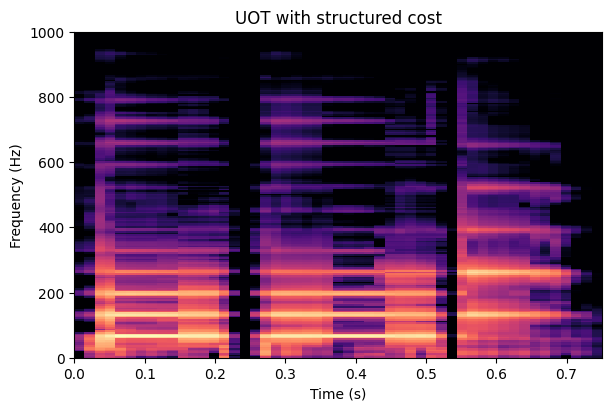

In [11]:
# take x.T.flatten() to vectorize (flatten) in a column-wise fashion (transpose)

x_UOT, loss_UOT, diff_UOT = uot_barycenter(x1.T.flatten(), 
                                           x2.T.flatten(), 
                                           c1, 
                                           c2, 
                                           rows1,
                                           cols1,
                                           rows2,
                                           cols2,
                                           eta=5,
                                           bary_size=X1.f_bins.size * X2.t_frames.size,
                                           nItermax=1000,
                                           verbose=False,
                                           return_loss=True,
                                           return_diff=True,
                                           thr=0) # force 1000 iterations like for OT

x_UOT = x_UOT.reshape(X2.t, X1.f).T # reshape vector to spectrogram shape

display_spectrogram(x_UOT, f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='UOT with structured cost')

### Display 4 spectrograms

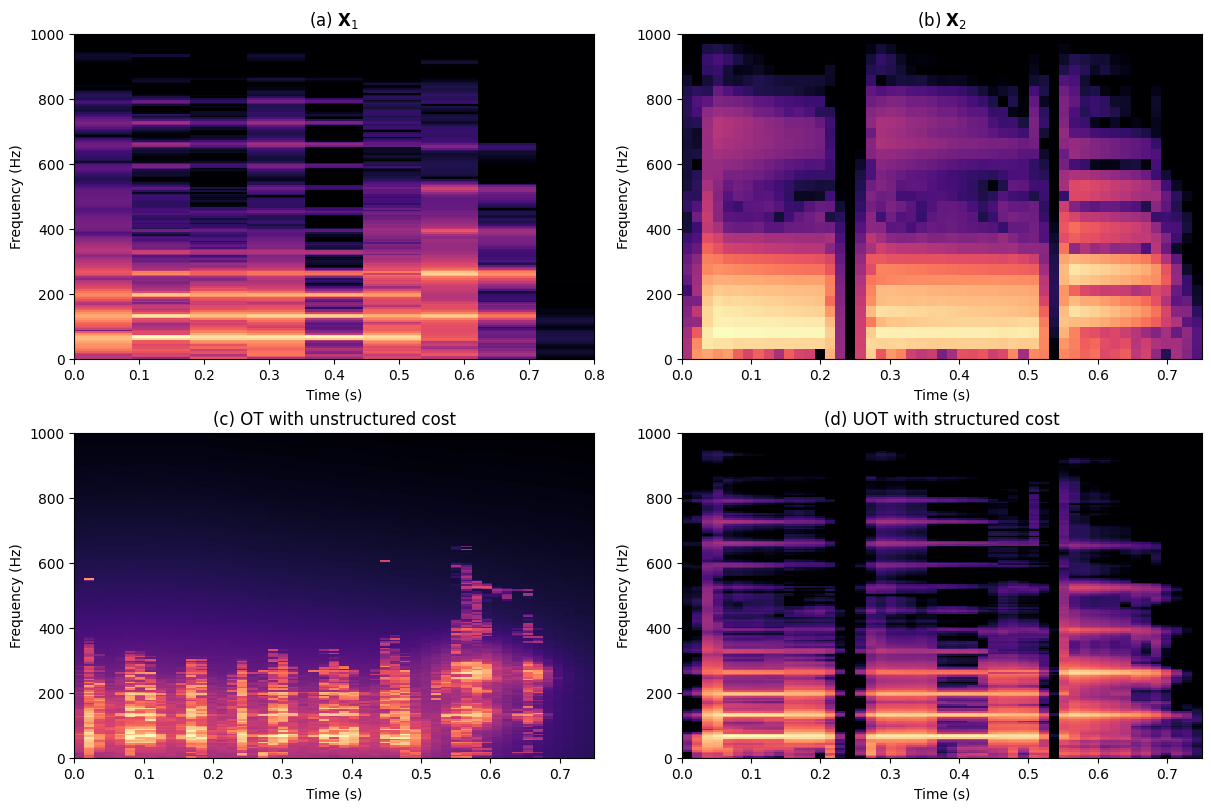

In [12]:
axes = new_axes(2, 2)

display_spectrogram(x1   , ax=axes[0, 0], f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-80, title=r"(a) $\mathbf{X}_1$")
display_spectrogram(x2   , ax=axes[0, 1], f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-80, title=r"(b) $\mathbf{X}_2$")
display_spectrogram(x_OT , ax=axes[1, 0], f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='(c) OT with unstructured cost')
display_spectrogram(x_UOT, ax=axes[1, 1], f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, title='(d) UOT with structured cost')


## Fig. 4 - Temporal windowing

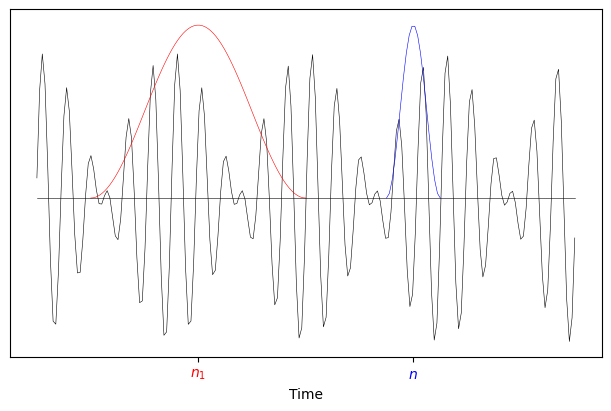

In [13]:
sr = 1000
t, signal = generate_toy_signal(sr=sr)

X1 = Spectrogram(signal, sr=sr, window_size_s=80e-3)
X2 = Spectrogram(signal, sr=sr, window_size_s=20e-3)

window_1 = X1.window.copy()
window_2 = X2.window.copy()

n_1 = 4  # index n_1
n   = 24 # index n

W1, W2 = X1.window_size, X2.window_size
H1, H2 = X1.hop_size, X2.hop_size

# truncate signal between 0.1 and 0.3 seconds for display
t_s, t_e = 0.10, 0.30
s_s, s_e = int(t_s * sr), int(t_e * sr)
t = np.linspace(t_s, t_e, s_e - s_s)
signal = signal[s_s:s_e]

# define windows' supports (see eq. 50)
t_s1, t_e1 = (n_1 * H1 - W1 / 2) / sr, (n_1 * H1 + W1 / 2) / sr
t_s2, t_e2 = (n * H2 - W2 / 2) / sr, (n * H2 + W2 / 2) / sr
T1 = np.linspace(t_s1, t_e1 , W1) # support of window 1
T2 = np.linspace(t_s2, t_e2 , W2) # support of window 2

# for better visualization
window_1 *= 1.2 * signal.max()
window_2 *= 1.2 * signal.max()

# timestamp of indexes n1 and n2
h_t1, h_t2 = (n_1 * H1) / sr, (n * H2) / sr

ax = new_axes()
plot_signal(signal, ax=ax, times=t)
ax.plot(T1, window_1, c='red', linewidth=.4, label=r'$W_1$')
ax.plot(T2, window_2, c='blue', linewidth=.4, label=r'$W_2$')
ax.plot(t, np.zeros_like(t), c='black', linewidth=.4) # plot line at origin

# add ticks for n and n'
ax.set_xticks([h_t1, h_t2])
ax.set_xticklabels([r"$n_1$", r"$n$"])
labs = ax.get_xticklabels()
labs[0].set_color('red')
labs[1].set_color('blue')

# other
ax.set_yticks([])
ax.set_xlabel('Time');


## Figs. 5 and 6, tables I and II - Synthetic signals

In [14]:
# Common STFT parameters

W1, W2         = 100e-3, 20e-3
hop_size, nfft = 2e-3, 512
dur            = .5
sr             = 1000

## Compute supports and cost matrices for UOT (same-grid and different-grid settings)
# Compute spectrogram of random signal to retrieve time and frequency samplings
signal = np.random.randn(int(dur * sr))

# same-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
f_bins, t_frames = X1.f_bins, X2.t_frames

c1_s, rows1_s, cols1_s = cost_matrix_horizontal_overlap(X1.f_bins, X2.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_s, rows2_s, cols2_s = cost_matrix_vertical_overlap(X1.f_bins, X1.f_bins, X2.t_frames, X1.window_size, X2.window_size)

# different-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=W1 / 4, nfft=nfft) # 75% overlap
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=None) # complete frequency sampling

c1_d, rows1_d, cols1_d = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_d, rows2_d, cols2_d = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

print(f"M1: {X1.f}, N1: {X1.t}")
print(f"M2: {X2.f}, N2: {X2.t}")

print(f"Temporal spacing {t_frames[1]}.")
print(f"Frequency spacing {f_bins[1]}.")

print("\nDifferent-grid setting, cost matrices finite entries:\n")
print(rf'C1 finite entries {c1_d.size}')
print(rf'C2 finite entries {c2_d.size}')

print("\nDifferent-grid setting, cost matrices finite entries:")
print(rf'C1 finite entries {c1_s.size}')
print(rf'C2 finite entries {c2_s.size}')

M1: 257, N1: 22
M2: 11, N2: 255
Temporal spacing 0.002.
Frequency spacing 1.953125.

Different-grid setting, cost matrices finite entries:

C1 finite entries 308657
C2 finite entries 303450

Different-grid setting, cost matrices finite entries:
C1 finite entries 3758625
C2 finite entries 7096395


Load experiment results

In [15]:
# single tf packet

t_error, f_error        = {}, {}
runtime_s, iterations_s = {}, {}


t_error["x1"]             = np.load("data/SINGLE_TF_error_time_x1.npy")
t_error["x2"]             = np.load("data/SINGLE_TF_error_time_x2.npy")
t_error["xg"]             = np.load("data/SINGLE_TF_error_time_xg.npy")
t_error["xs"]             = np.load("data/SINGLE_TF_error_time_xs.npy")
t_error["xd"]             = np.load("data/SINGLE_TF_error_time_xd.npy")
f_error["x1"]             = np.load("data/SINGLE_TF_error_freq_x1.npy")
f_error["x2"]             = np.load("data/SINGLE_TF_error_freq_x2.npy")
f_error["xg"]             = np.load("data/SINGLE_TF_error_freq_xg.npy")
f_error["xs"]             = np.load("data/SINGLE_TF_error_freq_xs.npy")
f_error["xd"]             = np.load("data/SINGLE_TF_error_freq_xd.npy")
runtime_s["same-grid"]    = np.load("data/SINGLE_TF_runtime_s.npy")
runtime_s["diff-grid"]    = np.load("data/SINGLE_TF_runtime_d.npy")
iterations_s["same-grid"] = np.load("data/SINGLE_TF_iterations_s.npy")
iterations_s["diff-grid"] = np.load("data/SINGLE_TF_iterations_d.npy")

# mixture packets

overall_error             = {}
runtime_m, iterations_m   = {}, {}
overall_error["x1"]       = np.load("data/MULTI_TF_error_overall_x1.npy")
overall_error["x2"]       = np.load("data/MULTI_TF_error_overall_x2.npy")
overall_error["xg"]       = np.load("data/MULTI_TF_error_overall_xg.npy")
overall_error["xs"]       = np.load("data/MULTI_TF_error_overall_xs.npy")
overall_error["xd"]       = np.load("data/MULTI_TF_error_overall_xd.npy")
runtime_m["same-grid"]    = np.load("data/MULTI_TF_runtime_s.npy")
runtime_m["diff-grid"]    = np.load("data/MULTI_TF_runtime_d.npy")
iterations_m["same-grid"] = np.load("data/MULTI_TF_iterations_s.npy")
iterations_m["diff-grid"] = np.load("data/MULTI_TF_iterations_d.npy")

### Table I

In [16]:
# Time to beat 1% error

tol = 1e-2

print(f"X1': Delta_t to beat {tol}: {t_frames[(t_error["x1"].mean(axis=0) < tol).argmax()]:.3f}")
print(f"X2': Delta_t to beat {tol}: {t_frames[(t_error["x2"].mean(axis=0) < tol).argmax()]:.3f}")
print(f"Geom: Delta_t to beat {tol}: {t_frames[(t_error["xg"].mean(axis=0) < tol).argmax()]:.3f}")
print(f"UOT (same grid): Delta_t to beat {tol}: {t_frames[(t_error["xs"].mean(axis=0) < tol).argmax()]:.3f}")
print(f"UOT (different grid): Delta_t to beat {tol}: {t_frames[(t_error["xd"].mean(axis=0) < tol).argmax()]:.3f}")

X1': Delta_t to beat 0.01: 0.026
X2': Delta_t to beat 0.01: 0.002
Geom: Delta_t to beat 0.01: 0.004
UOT (same grid): Delta_t to beat 0.01: 0.002
UOT (different grid): Delta_t to beat 0.01: 0.002


In [17]:
# Table I

N_sig = 100

print("Error in time:\n")

print(f"{'Spectrogram':<22} {'E_t x 10^{-2}':>18}")
print(f"{'X1':<23} {f'{t_error["x1"][:, 0].mean() * 100:.3f} ± {t_error["x1"][:, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'X2':<22} {f'{t_error["x2"][:, 0].mean() * 100:.3f} ± {t_error["x2"][:, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'Geom':<22} {f'{t_error["xg"][:, 0].mean() * 100:.3f} ± {t_error["xg"][:, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'UOT (same grid)':<22} {f'{t_error["xs"][:, 0].mean() * 100:.3f} ± {t_error["xs"][:, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{t_error["xd"][:, 0].mean() * 100:.3f} ± {t_error["xd"][:, 0].std() / np.sqrt(N_sig) * 100:.3f}':>18}")


Error in time:

Spectrogram                 E_t x 10^{-2}
X1                          39.029 ± 1.367
X2                          2.011 ± 0.246
Geom                        4.999 ± 0.460
UOT (same grid)             2.020 ± 0.246
UOT (different grid)        2.258 ± 0.266


### Table II

In [18]:
print("\nRuntime:\n\n")

print("Single packet:\n")
print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<25} {f'{runtime_s["same-grid"].mean():.3f} ± {runtime_s["same-grid"].std() / np.sqrt(N_sig):.3f}':>16} {f'{iterations_s["same-grid"].mean():.3f} ± {iterations_s["same-grid"].std() / np.sqrt(N_sig):.3f}':>17}")
print(f"{'UOT (different grid)':<22} {f'{runtime_s["diff-grid"].mean():.3f} ± {runtime_s["diff-grid"].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations_s["diff-grid"].mean():.3f} ± {iterations_s["diff-grid"].std() / np.sqrt(N_sig):.3f}':>18}")

print("\nMixture packets:\n")
print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<26} {f'{runtime_m["same-grid"].mean():.3f} ± {runtime_m["same-grid"].std() / np.sqrt(N_sig):.3f}':>16} {f'{iterations_m["same-grid"].mean():.3f} ± {iterations_m["same-grid"].std() / np.sqrt(N_sig):.3f}':>17}")
print(f"{'UOT (different grid)':<22} {f'{runtime_m["diff-grid"].mean():.3f} ± {runtime_m["diff-grid"].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations_m["diff-grid"].mean():.3f} ± {iterations_m["diff-grid"].std() / np.sqrt(N_sig):.3f}':>19}")


Runtime:


Single packet:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)             53.401 ± 1.029   469.110 ± 8.562
UOT (different grid)        0.431 ± 0.005     57.410 ± 0.542

Mixture packets:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)             119.339 ± 0.961   944.860 ± 4.991
UOT (different grid)        3.780 ± 0.084     472.310 ± 9.846


### Fig. 5


Text(0.5, 0, '$\\Delta_f$ (Hz)')

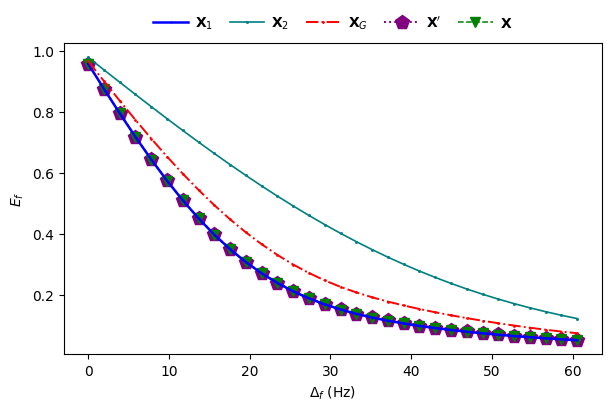

In [19]:
max_delta_f = 60
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, f_error["x1"].mean(axis=0)[:max_idx + 1],  ls='-',  marker='.', c='blue',   lw=1.8, ms=1,  zorder=5, label=r"$\mathbf{X}_1$")
axes.plot(x_axis, f_error["x2"].mean(axis=0)[:max_idx + 1],  ls='-',  marker='s', c='teal',   lw=1.2, ms=1,  zorder=3, label=r"$\mathbf{X}_2$")
axes.plot(x_axis, f_error["xg"].mean(axis=0)[:max_idx + 1],  ls='-.', marker='o', c='red',    lw=1.4, ms=1,  zorder=6, label=r"$\mathbf{X}_G$" )
axes.plot(x_axis, f_error["xs"].mean(axis=0)[:max_idx + 1],  ls=':',  marker='p', c='purple', lw=1.4, ms=10, zorder=2, label=r"$\mathbf{X}'$")
axes.plot(x_axis, f_error["xd"].mean(axis=0)[:max_idx + 1],  ls='--', marker='v', c='green',  lw=1.1, ms=7,  zorder=4, label=r"$\mathbf{X}$")


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E_f$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')


### Fig. 6

Text(0.5, 0, '$\\Delta_f$ (Hz)')

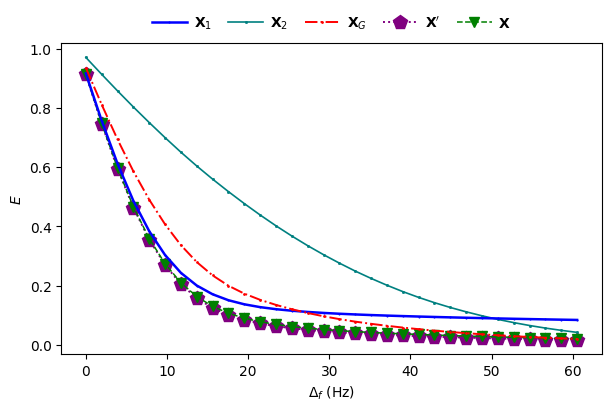

In [20]:
max_delta_f = 60
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, overall_error["x1"].mean(axis=0)[:max_idx + 1],  ls='-',  marker='.', c='blue',   lw=1.8, ms=1,  zorder=5, label=r"$\mathbf{X}_1$")
axes.plot(x_axis, overall_error["x2"].mean(axis=0)[:max_idx + 1],  ls='-',  marker='s', c='teal',   lw=1.2, ms=1,  zorder=3, label=r"$\mathbf{X}_2$")
axes.plot(x_axis, overall_error["xg"].mean(axis=0)[:max_idx + 1],  ls='-.', marker='o', c='red',    lw=1.4, ms=1,  zorder=6, label=r"$\mathbf{X}_G$" )
axes.plot(x_axis, overall_error["xs"].mean(axis=0)[:max_idx + 1],  ls=':',  marker='p', c='purple', lw=1.4, ms=10, zorder=2, label=r"$\mathbf{X}'$")
axes.plot(x_axis, overall_error["xd"].mean(axis=0)[:max_idx + 1],  ls='--', marker='v', c='green',  lw=1.1, ms=7,  zorder=4, label=r"$\mathbf{X}$")


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')


## Figs. 7 and 8, table III - Speech signals

Load experiment data

In [21]:
# single tf packet

harmonic_error       = {}
runtime, iterations = {}, {}


harmonic_error["x1"]     = np.load("data/SPEECH_error_harmonic_x1.npy")
harmonic_error["x2"]     = np.load("data/SPEECH_error_harmonic_x2.npy")
harmonic_error["xg"]     = np.load("data/SPEECH_error_harmonic_xg.npy")
harmonic_error["xs"]     = np.load("data/SPEECH_error_harmonic_xs.npy")
harmonic_error["xd"]     = np.load("data/SPEECH_error_harmonic_xd.npy")
runtime["same-grid"]    = np.load("data/SPEECH_runtime_s.npy")
runtime["diff-grid"]    = np.load("data/SPEECH_runtime_d.npy")
iterations["same-grid"] = np.load("data/SPEECH_iterations_s.npy")
iterations["diff-grid"] = np.load("data/SPEECH_iterations_d.npy")


### Load signal to display

In [22]:
# Common STFT parameters
W1, W2         = 100e-3, 20e-3
hop_size, nfft = 5e-3, 1024

## Compute supports and cost matrices for UOT (same-grid and different-grid settings)

# Load signal to display in Fig. 8
sr = 8000

source_folder     = 'example_sounds/PTDB-TUG/'
signal_to_display = 'M04_si1066'
signal, _         = librosa.load(source_folder + signal_to_display + '/signal.wav', sr=sr)

# pad signal to max duration
max_duration_s = 6
pad_length = int(max_duration_s * sr) - signal.size
signal = np.pad(signal, (0, pad_length))

# Compute spectrogram of signal to retrieve time and frequency samplings

# same-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
f_bins, t_frames = X1.f_bins, X2.t_frames

c1_s, rows1_s, cols1_s = cost_matrix_horizontal_overlap(X1.f_bins, X2.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_s, rows2_s, cols2_s = cost_matrix_vertical_overlap(X1.f_bins, X1.f_bins, X2.t_frames, X1.window_size, X2.window_size)

# different-grid setting
X1 = Spectrogram(signal, sr, W1, hop_size_s=W1 / 4, nfft=nfft) # 75% overlap
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=None) # complete frequency sampling

c1_d, rows1_d, cols1_d = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2_d, rows2_d, cols2_d = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

print(f"M1: {X1.f}, N1: {X1.t}")
print(f"M2: {X2.f}, N2: {X2.t}")

print(f"\nTemporal spacing {t_frames[1]}.")
print(f"Frequency spacing {f_bins[1]}.")

print("\nDifferent-grid setting, cost matrices finite entries:\n")
print(rf'C1 finite entries {c1_d.size}')
print(rf'C2 finite entries {c2_d.size}')

print("\nDifferent-grid setting, cost matrices finite entries:")
print(rf'C1 finite entries {c1_s.size}')
print(rf'C2 finite entries {c2_s.size}')

M1: 513, N1: 242
M2: 81, N2: 1202

Temporal spacing 0.005.
Frequency spacing 7.8125.

Different-grid setting, cost matrices finite entries:

C1 finite entries 3075435
C2 finite entries 2971344

Different-grid setting, cost matrices finite entries:
C1 finite entries 15335622
C2 finite entries 18826926


Fig. 7

Text(0.5, 0, '$\\Delta_f$ (Hz)')

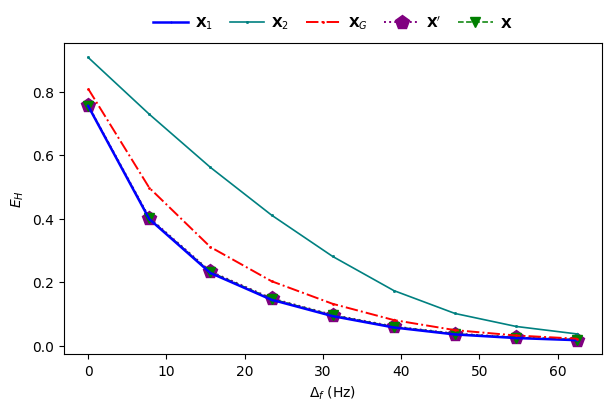

In [23]:
max_delta_f = 60
max_idx = idx_at_value(max_delta_f, f_bins)
x_axis = f_bins[:max_idx + 1]
axes = new_axes()

axes.plot(x_axis, harmonic_error["x1"].mean(axis=0)[:max_idx + 1], ls='-',  marker='.', c='blue',   lw=1.8, ms=1,  zorder=5, label=r"$\mathbf{X}_1$")
axes.plot(x_axis, harmonic_error["x2"].mean(axis=0)[:max_idx + 1], ls='-',  marker='s', c='teal',   lw=1.2, ms=1,  zorder=3, label=r"$\mathbf{X}_2$")
axes.plot(x_axis, harmonic_error["xg"].mean(axis=0)[:max_idx + 1], ls='-.', marker='o', c='red',    lw=1.4, ms=1,  zorder=6, label=r"$\mathbf{X}_G$" )
axes.plot(x_axis, harmonic_error["xs"].mean(axis=0)[:max_idx + 1], ls=':',  marker='p', c='purple', lw=1.4, ms=10, zorder=2, label=r"$\mathbf{X}'$")
axes.plot(x_axis, harmonic_error["xd"].mean(axis=0)[:max_idx + 1], ls='--', marker='v', c='green',  lw=1.1, ms=7,  zorder=4, label=r"$\mathbf{X}$")


axes.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5,
    frameon=False,
    handlelength=2.5,
    columnspacing=1.2,
    handletextpad=0.5,
    borderaxespad=0.0
)

axes.set_ylabel(r'$E_H$')
axes.set_xlabel(r'$\Delta_f$ (Hz)')


Table III

In [24]:
N_sig = 100

print("\nRuntime:\n")

print(f"{'UOT barycenter':<22} {'Runtime (s)':>16} {'Iterations':>16}")
print(f"{'UOT (same grid)':<22} {f'{runtime["same-grid"].mean():.3f} ± {runtime["same-grid"].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations["same-grid"].mean():.3f} ± {iterations["same-grid"].std() / np.sqrt(N_sig):.3f}':>18}")
print(f"{'UOT (different grid)':<22} {f'{runtime["diff-grid"].mean():.3f} ± {runtime["diff-grid"].std() / np.sqrt(N_sig):.3f}':>18} {f'{iterations["diff-grid"].mean():.3f} ± {iterations["diff-grid"].std() / np.sqrt(N_sig):.3f}':>18}")


Runtime:

UOT barycenter              Runtime (s)       Iterations
UOT (same grid)           148.938 ± 4.117    341.440 ± 9.406
UOT (different grid)        9.356 ± 0.214    104.800 ± 2.397


### Compute barycenters for Fig. 8

In [26]:
eta = 1
nItermax = 2000
tol = 5e-7

## same-grid
X1_s = Spectrogram(signal, sr, W1, hop_size_s=hop_size, nfft=nfft)
X2_s = Spectrogram(signal, sr, W2, hop_size_s=hop_size, nfft=nfft)
x1_s, x2_s = X1_s.spectrogram(), X2_s.spectrogram()
x1_s = x1_s[:, :X2_s.t] # crop last frames to ensure same size

# uot barycenter
x_s, iter_s = uot_barycenter(x1_s.T.flatten(), 
                                x2_s.T.flatten(), 
                                c1_s, 
                                c2_s, 
                                rows1_s,
                                cols1_s,
                                rows2_s,
                                cols2_s,
                                eta=eta,
                                bary_size=f_bins.size * t_frames.size,
                                nItermax=nItermax,
                                verbose=False,
                                return_iter=True,
                                thr=tol)
x_s = x_s.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

# geometric mean
x_g = (x1_s * x2_s)**.5

## different-grid

X1_d = Spectrogram(signal, sr, W1, hop_size_s=W1/4, nfft=nfft)
X2_d = Spectrogram(signal, sr, W2, hop_size_s=hop_size)
x1_d, x2_d = X1_d.spectrogram(), X2_d.spectrogram()

# uot barycenter
x_d, iter_d = np.zeros_like(x1_s), 0
x_d, iter_d = uot_barycenter(x1_d.T.flatten(), 
                                x2_d.T.flatten(), 
                                c1_d, 
                                c2_d, 
                                rows1_d,
                                cols1_d,
                                rows2_d,
                                cols2_d,
                                eta=eta,
                                bary_size=f_bins.size * t_frames.size,
                                nItermax=nItermax,
                                verbose=False,
                                return_iter=True,
                                thr=tol)

x_d = x_d.reshape(t_frames.size, f_bins.size).T # reshape vector to spectrogram shape

Fig. 8

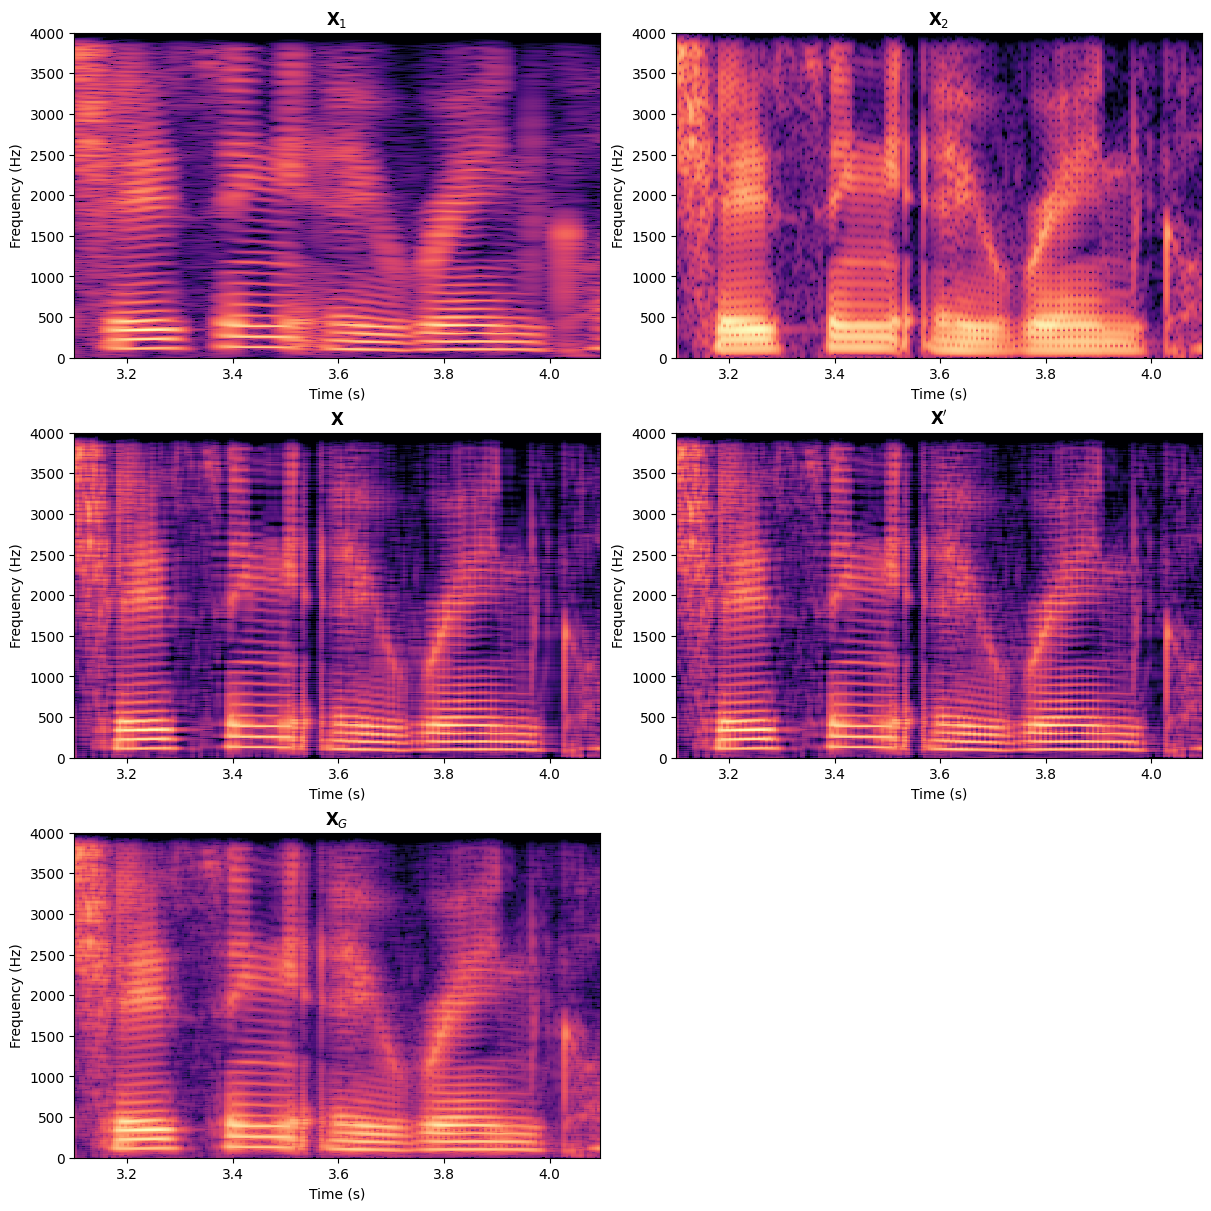

In [27]:
low_t, high_t = 3.1, 4.1
axes = new_axes(3, 2)
display_spectrogram(x1_s, ax=axes[0, 0], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t, title=r"$\mathbf{X}_1$")
display_spectrogram(x2_s, ax=axes[0, 1], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t, title=r"$\mathbf{X}_2$")
display_spectrogram(x_d,  ax=axes[1, 0], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t, title=r"$\mathbf{X}$" )
display_spectrogram(x_s,  ax=axes[1, 1], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t, title=r"$\mathbf{X}'$")
display_spectrogram(x_g,  ax=axes[2, 0], f_bins=f_bins, t_frames=t_frames, log=True, low_t=low_t, high_t=high_t, title=r"$\mathbf{X}_G$")
axes[2, 1].set_axis_off()

# Supplementary material

## Fig. 9 - Fourier transform of Hann window

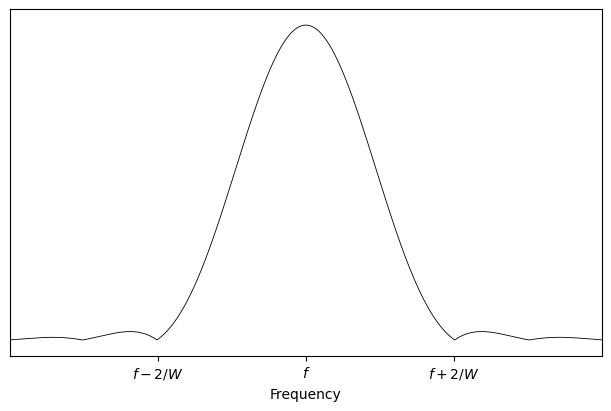

In [28]:
sr = 8000
window_size_seconds = 20e-3

window = hann(int(sr * window_size_seconds))
window_ft = np.fft.fft(window, n=100000)
window_ft = np.abs(window_ft)
freqs = np.fft.fftfreq(window_ft.size, d=1/sr)

window_ft = np.fft.fftshift(window_ft) # center at f=0Hz.
freqs = np.fft.fftshift(freqs)

axes = new_axes()
axes.set_yticks([])
axes.plot(freqs, window_ft, c='black', linewidth=.6)
axes.set_xlabel("Frequency")
axes.set_xticks([-2 / window_size_seconds, 0,  2 / window_size_seconds])
axes.set_xticklabels([r"$f -2 / W$", r"$f$", r"$f +2 / W$"]);
axes.set_xlim(-200, 200);

## Figs. 10 and 11 - Target mel-frequency axis support

Fig. 10 - Mel support

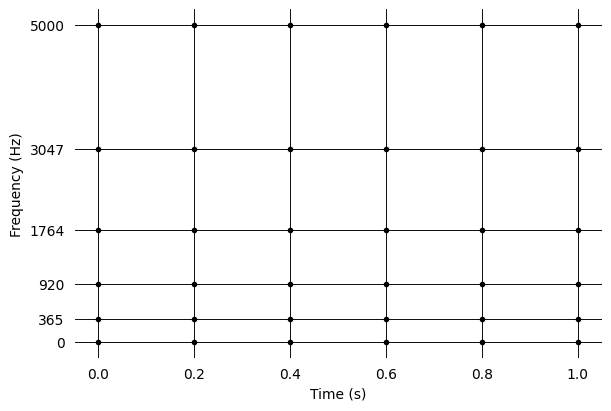

In [29]:
sr = 10000

m_bins = mel_frequency_bins(6, sr)
t_frames   = np.linspace(0, 1, 6)

S_mel = time_freq_support(m_bins, t_frames, norm=False)

display_support(S_mel)

We first compute a barycenter directly on the mel scale between $\mathbf{X}_1$ and $\mathbf{X}_2$. We compare it with:

* Mel spectrogram of $\mathbf{X}_1$ computed using traditional pipeline.
* Mel spectrogram of $\mathbf{X}_2$ computed using traditional pipeline.
* 2-step super resolution mel: (i) compute super-resolution between $\mathbf{X}_1$ and $\mathbf{X}_2$ (ii) compute mel using traditional pipeline


Convergence attained after 277 iterations.
Convergence attained after 124 iterations.


/Users/davidv/david/code/papers/fusion-ot/.venv/lib/python3.14/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


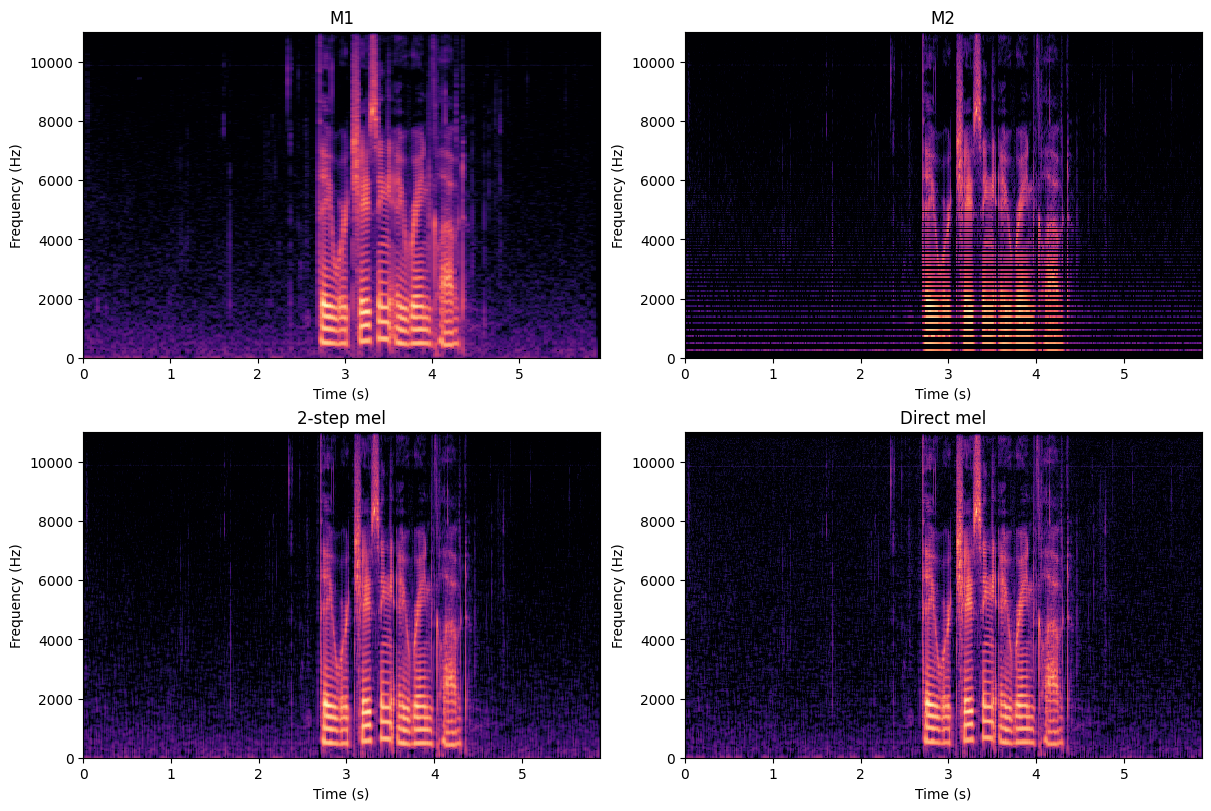

In [30]:
sr = 22050
signal, _ = librosa.load('example_sounds/example_speech.wav', sr=sr)

W1, W2 = 100e-3, 20e-3
nfft = int(sr // 7.815) # retain frequency spacing of Section VI
hop_size = 5e-3

# different-grid spectrograms for UOT
X1 = Spectrogram(signal, sr, W1, hop_size_s=W1/4, nfft=nfft)
X2 = Spectrogram(signal, sr, W2, hop_size_s=hop_size)

x1 = X1.spectrogram()
x2 = X2.spectrogram()

n_bins = 300
m_bins = mel_frequency_bins(n_bins, sr)

# direct mel
c1, rows1, cols1 = cost_matrix_horizontal_overlap_mel(X1.f_bins, m_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, sr, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap_mel(m_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size, sr)

# c1 /= c1.max()
# c2 /= c2.max()

tol = 5e-7

x_mel = uot_barycenter(x1.T.flatten(), 
                       x2.T.flatten(), 
                       c1, 
                       c2, 
                       rows1,
                       cols1,
                       rows2,
                       cols2,
                       eta=1,
                       bary_size= m_bins.size * X2.t,
                       nItermax=2000,
                       verbose=True,
                       return_loss=False,
                       return_diff=False,
                       thr=tol)

x_mel = x_mel.reshape(X2.t, m_bins.size).T

# 2-step mel

c1, rows1, cols1 = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

x_uot = uot_barycenter(x1.T.flatten(), 
                       x2.T.flatten(), 
                       c1, 
                       c2, 
                       rows1,
                       cols1,
                       rows2,
                       cols2,
                       eta=1,
                       bary_size=x1.shape[0] * x2.shape[1],
                       nItermax=2000,
                       verbose=True,
                       return_loss=False,
                       return_diff=False,
                       thr=tol)


x_uot = x_uot.reshape(X2.t, X1.f).T
x_uot_mel = librosa.feature.melspectrogram(S=x_uot, n_mels=n_bins, htk=True)

# Mel spectrograms of X1 and X2

m1 = librosa.feature.melspectrogram(S=x1, n_mels=n_bins, htk=True)
m2 = librosa.feature.melspectrogram(S=x2, n_mels=n_bins, htk=True)

axes = new_axes(2, 2)
display_spectrogram(m1,        ax=axes[0, 0], title='M1',         f_bins=m_bins, t_frames=X1.t_frames, log=True)
display_spectrogram(m2,        ax=axes[0, 1], title='M2',         f_bins=m_bins, t_frames=X2.t_frames, log=True)
display_spectrogram(x_uot_mel, ax=axes[1, 0], title='2-step mel', f_bins=m_bins, t_frames=X2.t_frames, log=True)
display_spectrogram(x_mel,     ax=axes[1, 1], title='Direct mel', f_bins=m_bins, t_frames=X2.t_frames, log=True)

Fig. 11 - Compare super-resolution mel with another mel

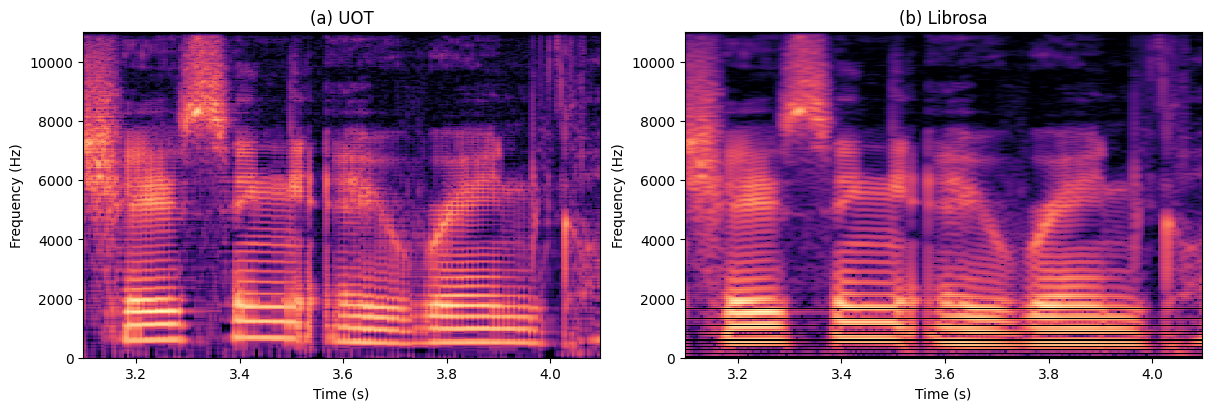

In [31]:
# Other spectrogram to compare with

low_t, high_t = 3.1, 4.1

X3 = Spectrogram(signal, sr, window_size_s=40e-3, hop_size_s=X2.hop_size_s, nfft=1024)
m3 = librosa.feature.melspectrogram(S=X3.spectrogram(), n_mels=x_mel.shape[0], htk=True)

axes = new_axes(1, 2)
display_spectrogram(x_mel, ax=axes[0], title='(a) UOT',  f_bins=m_bins, t_frames=X2.t_frames, log=True, low_t=low_t, high_t=high_t)
display_spectrogram(m3, ax=axes[1], title='(b) Librosa', f_bins=m_bins, t_frames=X3.t_frames, log=True, low_t=low_t, high_t=high_t)

In [32]:
EXP_PATH = '../../these/fusion/exps/paper_figures/'

np.save(EXP_PATH + 'bass_uot.npy', x_UOT)